In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = "../logs/cluster/logs"

def load_rewards(category, name):
    path = os.path.join(base_path, category, name, "episode_rewards.npy")
    return np.load(path)

data = {
    "er_base": load_rewards("er", "checkpoint3_strong_er_baseline"),
    "er_custom": load_rewards("er", "checkpoint3_strong_er_custom_reward"),
    "er_shaping": load_rewards("er", "checkpoint3_strong_er_reward_shaping"),
    "per_base": load_rewards("per", "checkpoint3_strong_per_baseline"),
    "per_custom": load_rewards("per", "checkpoint3_strong_per_custom_reward"),
    "per_shaping": load_rewards("per", "checkpoint3_strong_per_reward_shaping"),
}

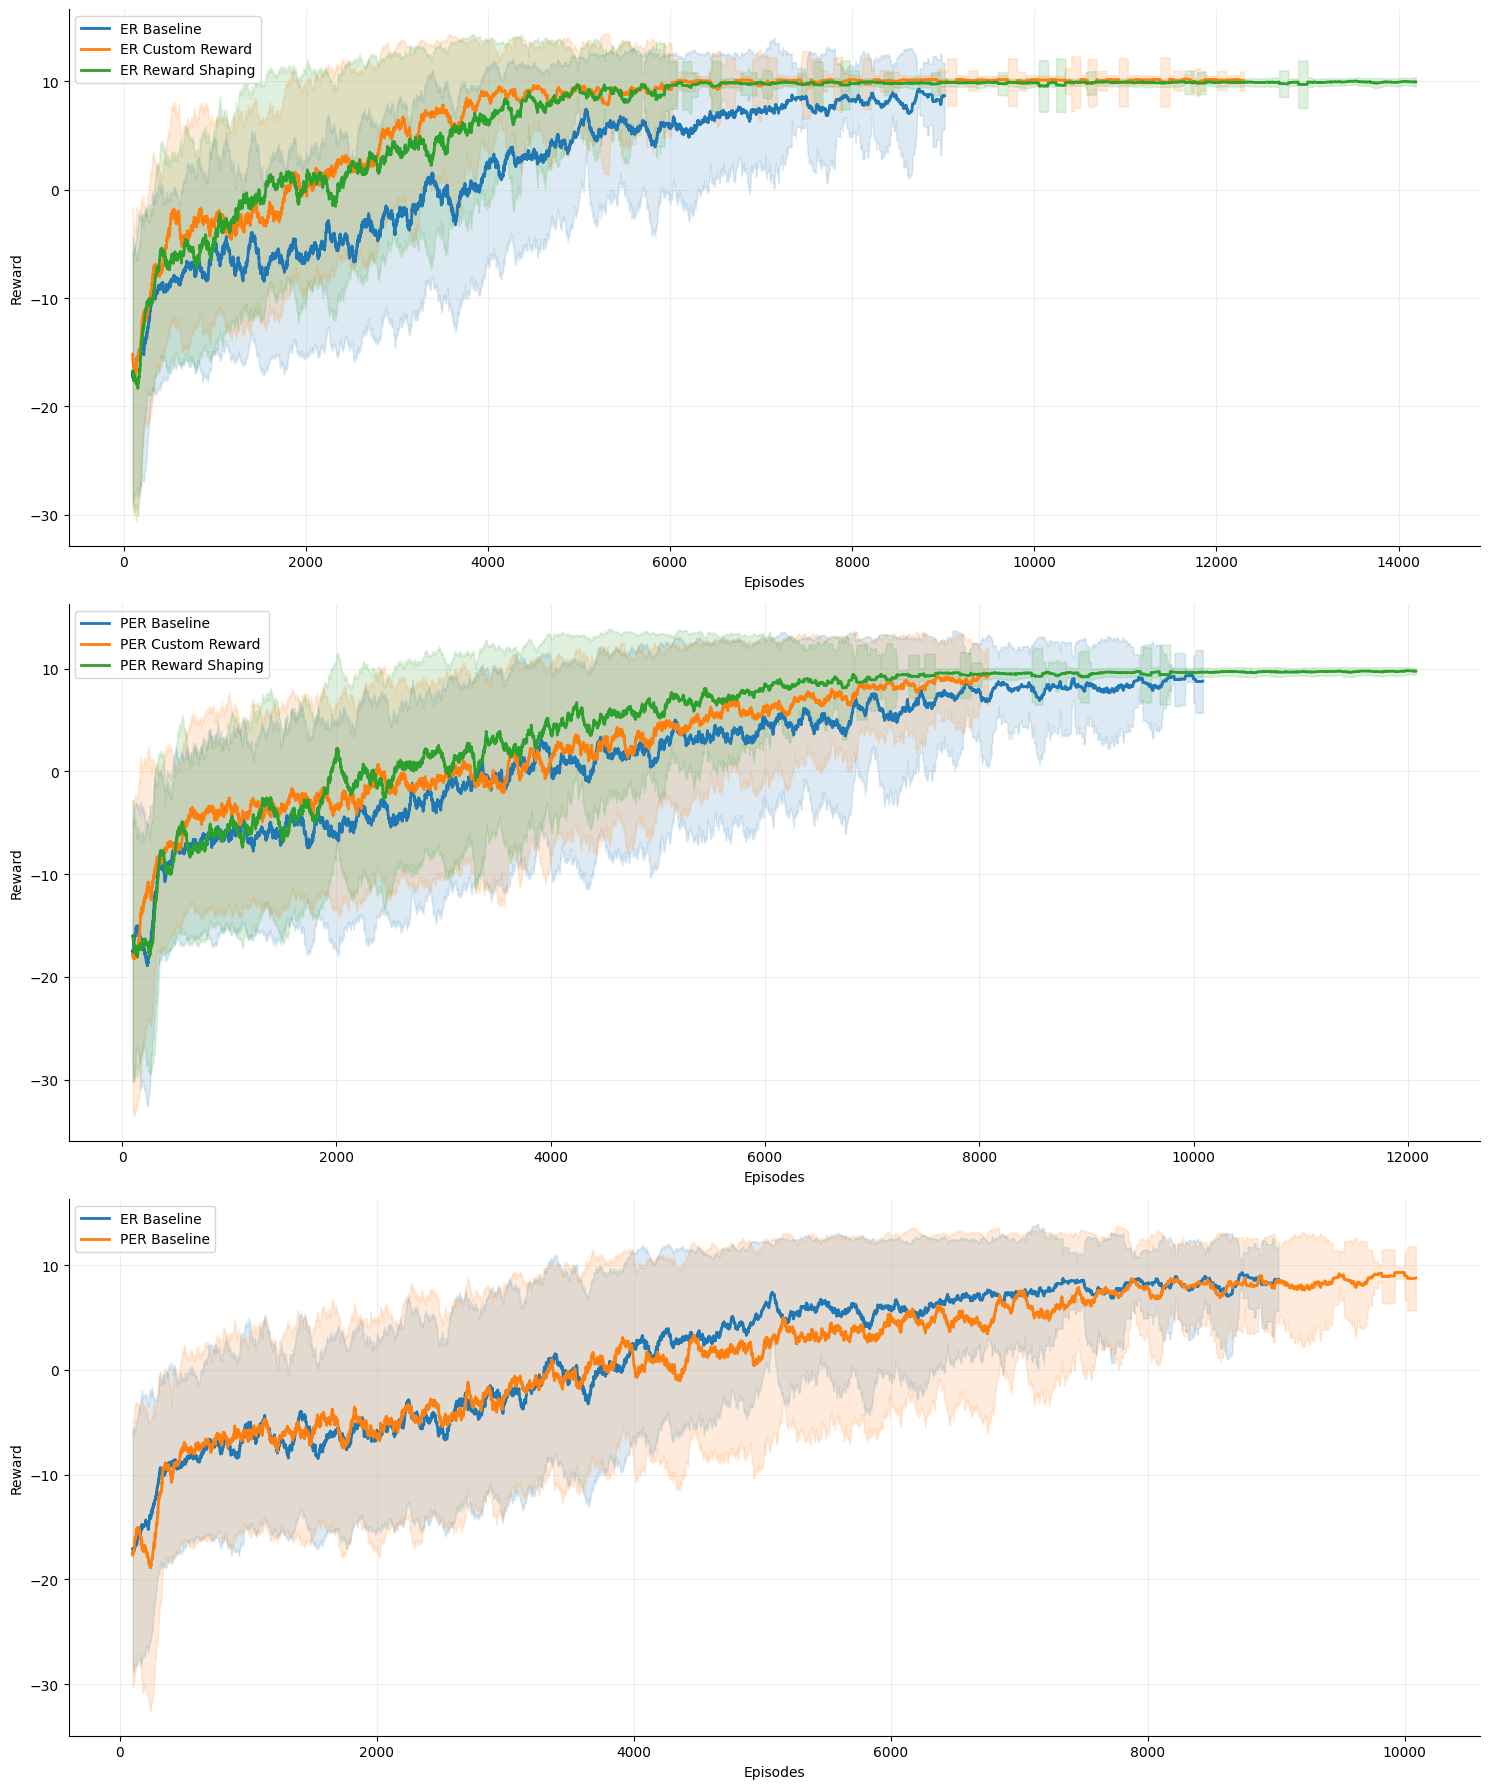

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reward(ax, data, label, color, window=100):
    window = min(window, len(data) // 5)
    if window < 2: window = 2
    moving_avg = np.convolve(data, np.ones(window)/window, mode='valid')
    std = np.array([np.std(data[i:i+window]) for i in range(len(moving_avg))])
    x_axis = np.arange(window - 1, len(data))
    
    ax.plot(x_axis, moving_avg, label=label, color=color, linewidth=2)
    ax.fill_between(x_axis, moving_avg - std, moving_avg + std, color=color, alpha=0.15)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axs = plt.subplots(3, 1, figsize=(15, 18))

# Plot 1: ER
plot_reward(axs[0], data["er_base"], "ER Baseline", colors[0])
plot_reward(axs[0], data["er_custom"], "ER Custom Reward", colors[1])
plot_reward(axs[0], data["er_shaping"], "ER Reward Shaping", colors[2])

# Plot 2: PER
plot_reward(axs[1], data["per_base"], "PER Baseline", colors[0])
plot_reward(axs[1], data["per_custom"], "PER Custom Reward", colors[1])
plot_reward(axs[1], data["per_shaping"], "PER Reward Shaping", colors[2])

# Plot 3: Comparison Baselines
plot_reward(axs[2], data["er_base"], "ER Baseline", colors[0])
plot_reward(axs[2], data["per_base"], "PER Baseline", colors[1])

for ax in axs:
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper left')
    ax.set_ylabel("Reward")
    ax.set_xlabel("Episodes")

plt.tight_layout()
plt.show()